# Mean Flow MatchingMean flow matching for generative modeling.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import LinearMeanFlow

import importlib


importlib.import_module("examples.nn.examples")
from examples.nn.examples import CheckerboardGenerator, SpiralGenerator, CrescentGenerator


In [81]:
l, state = jax.grad(loss, has_aux=True)(params,state)

In [82]:
print(jax.tree_util.tree_reduce(lambda x, y: x + y, jax.tree_util.tree_map(lambda x: x.sum(), l)))

-387.66888


In [15]:
gen = CheckerboardGenerator()
data = gen.generate(1000000, jax.random.PRNGKey(0))


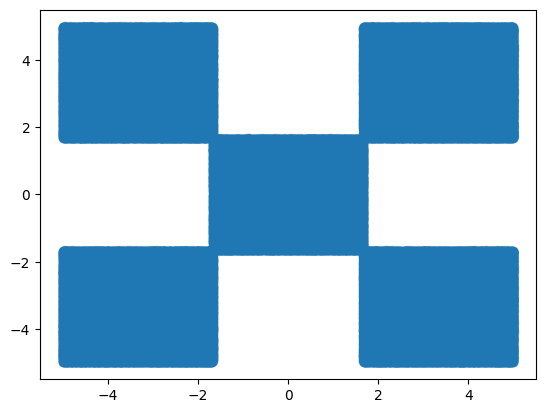

In [16]:
plt.scatter(data[:,0], data[:,1], alpha=0.1)

In [79]:
from probjax.nn.nets.simple import ResNet, MLP


class BaseModel(nnx.Module):
    def __init__(self, d, rngs, time_embed_dim=64, hidden_dim=256) -> None:
        self.time_embedding1 = GaussianFourierEmbedding(1,time_embed_dim//2, rngs=rngs)
        self.time_embedding2 = GaussianFourierEmbedding(1,time_embed_dim//2, rngs=rngs)
        self.resnet = ResNet(d,d,rngs=rngs,context_dim=time_embed_dim, num_hidden_layers=3, hidden_dim=hidden_dim, norm_cls=nnx.LayerNorm)
    def __call__(self, t,x, *, r: jax.Array, **kwargs):
        r_embed = self.time_embedding1(r-t)
        t_embed = self.time_embedding2(t)
        rt_embed = jnp.concatenate([r_embed, t_embed], axis=-1)
        v = self.resnet(x, context=rt_embed)
        return v

net = BaseModel(2, nnx.Rngs(0))
model = LinearMeanFlow(net,std0=1., std1=data.std(0))
params = nnx.state(model, nnx.Param)

In [80]:

import optax

def loss_fn(params, rng, x):
    nnx.update(model, params)
    return model.loss(rng, x, adaptive_weight_p=0.3)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [81]:
import optax

opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(1e-4))
opt_state = opt.init(params)


In [82]:
key = jax.random.key(42)

In [83]:
losses = []
for i in range(1000):
    l = 0.
    for j in range(100):
        key,key_data, key_loss = jax.random.split(key, 3)
        #xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        xs = jax.random.choice(key_data, data, (1_000,), axis=0)
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/100)

(1000, 2) (1000, 2)


KeyboardInterrupt: 

In [84]:
nnx.update(model, params)

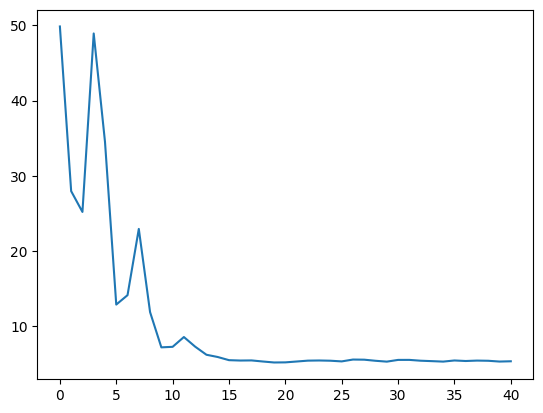

In [85]:
# Its actually good if the loss goes up here xD Thats due to the stop_gradient i.e. its more like a fixed point iteration.

plt.plot(losses)

In [86]:
nnx.update(model, params)

In [87]:
d = 2
def sample(rng, numsteps=32):
    xt = jax.random.normal(rng, (d,))
    ts = jnp.linspace(0, 1, numsteps + 1)
    for i in range(numsteps):
        t = ts[i]
        r = ts[i + 1]
        print(t,r)
        u = model(jnp.array([t]), xt, r=jnp.array([r]))
        xt = xt + u * (r-t)
    return xt

In [88]:
from functools import partial
samples = jax.vmap(partial(sample, numsteps=8))(jax.random.split(jax.random.PRNGKey(0), 40000))

0.0 0.125
0.125 0.25
0.25 0.375
0.375 0.5
0.5 0.625
0.625 0.75
0.75 0.875
0.875 1.0


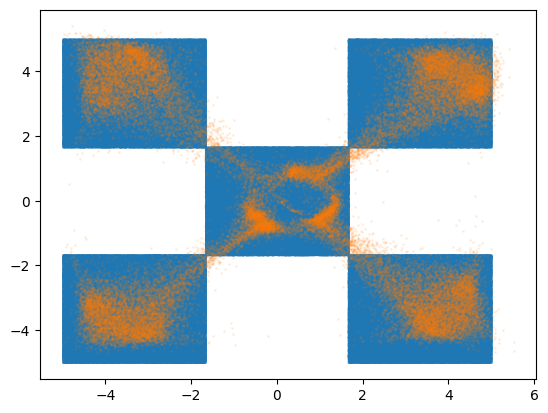

In [89]:
plt.scatter(data[:,0], data[:,1], alpha=0.1, s=1)
plt.scatter(samples[:,0], samples[:,1], alpha=0.1, s=1)

In [ ]:
gen = SpiralGenerator()
data = gen.generate(10000, jax.random.PRNGKey(0))

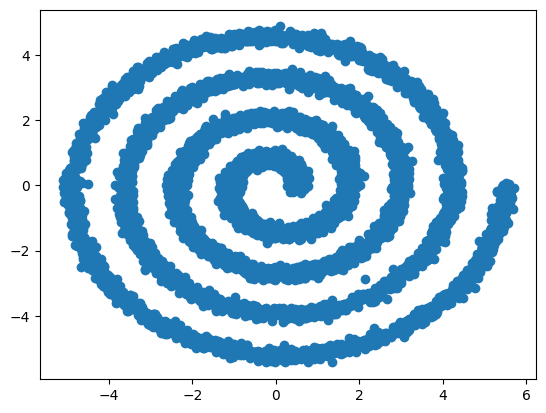

In [117]:
plt.scatter(data[:,0], data[:,1])

In [119]:

net = BaseModel(2, nnx.Rngs(0))
model = LinearMeanFlow(net,std0=1., std1=data.std(0))
params = nnx.state(model, nnx.Param)

scheduler = optax.cosine_onecycle_schedule(40000, 1e-4)
opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(scheduler))
opt_state = opt.init(params)


In [ ]:
losses = []
for i in range(400):
    l = 0.
    for j in range(100):
        key,key_data, key_loss = jax.random.split(key, 3)
        #xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        xs = jax.random.choice(key_data, data, (5_000,), axis=0)
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/100)

2025-08-01 15:15:11.789498: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-08-01 15:15:11.789543: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [121]:
nnx.update(model, params)

0.0 0.25
0.25 0.5
0.5 0.75
0.75 1.0


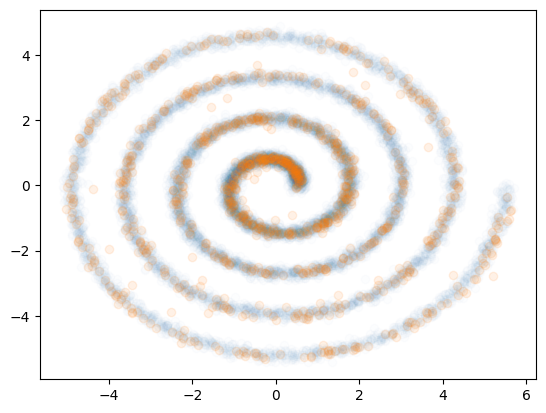

In [126]:
from functools import partial
samples = jax.vmap(partial(sample, numsteps=4))(jax.random.split(jax.random.PRNGKey(0), 1000))
plt.scatter(data[:,0], data[:,1], alpha=0.01)
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)